# Full-Tree Pareto Optimization

Reconstruct the entire *C. elegans* lineage tree by assigning cell identities
to tree nodes, trading off spatial proximity vs expression similarity.

Uses top20 z-scored protein expression (matching `run_pipeline_multi.py`),
3 hardcoded untracked ancestral nodes (P0, AB, P1), dynamic first_layer.

In [1]:
import pandas as pd, numpy as np, json, os, sys
from pathlib import Path
from collections import defaultdict, deque
from tqdm import tqdm
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cosine
import matplotlib.pyplot as plt, seaborn as sns
from matplotlib.lines import Line2D
import matplotlib as mpl; mpl.rcParams['figure.dpi'] = 150; sns.set_style('whitegrid')
_cwd = Path.cwd().resolve()
MODULE_DIR = _cwd if _cwd.name == 'full_tree_pareto' else _cwd / 'full_tree_pareto'
PROJECT_ROOT = MODULE_DIR.parent
CACHE_ROOT = MODULE_DIR / 'output' / 'internal_opt'
sys.path.insert(0, str(PROJECT_ROOT))
from utils import lineage_name_mapping as map_names, load_json
from pareto_core import LineageTree, LineageOptimization

In [2]:
OUT_DIR = CACHE_ROOT / 'celegans_prot/embryo1'
NULL_DIR = os.path.join(OUT_DIR, 'null')
HEUR_DIR = os.path.join(OUT_DIR, 'heuristics')
os.makedirs(NULL_DIR, exist_ok=True); os.makedirs(HEUR_DIR, exist_ok=True)
print(f'Output: {OUT_DIR}')

# All config output directories (for cross-config loading)
CONFIGS = {
    'C. elegans Protein (3D, T≤255)':  CACHE_ROOT / 'celegans_prot/embryo1',
    'C. elegans RNA (2D, T≤230)':      CACHE_ROOT / 'celegans_rna_2d/embryo1',
    'C. briggsae RNA (2D, T≤148)':     CACHE_ROOT / 'briggsae_rna_2d/embryo1',
}
LINEAGE_COSTS = {
    'C. elegans Protein (3D, T≤255)':   (4465.5, 3102.4),
    'C. elegans RNA (2D, T≤230)':       (2553.6, 729014.5),
    'C. briggsae RNA (2D, T≤148)':      (41159.5, 963757.9),
}

Output: output/internal_opt/celegans_prot/embryo1


In [3]:
# ═══════════════════════════════════════════════════════
# DATA LOADING — matching run_pipeline_multi.py embryo1_prot
# ═══════════════════════════════════════════════════════

lineage_data = load_json(PROJECT_ROOT / 'data/cell_lineage.json')

# Expression: top20 z-scored proteins (matching pipeline)
prot_exp = pd.read_csv(PROJECT_ROOT / 'data/protein/aggregated_all/s3_zscore.csv', index_col=0).T
prot_sel = pd.read_csv(PROJECT_ROOT / 'expression_embedding/results/elegans_protein_linear_baseline/top20_protein_names.csv')
prot_sel = prot_sel['protein'].tolist()
available = [f for f in prot_sel if f in prot_exp.columns]
lineage_exp_df = prot_exp[available].fillna(0)
print(f'Expression: {lineage_exp_df.shape[0]} cells × {lineage_exp_df.shape[1]} proteins (top20 z-scored)')

# Tracking: embryo1, T <= 255
TRACKING_SCALE = 0.1625
tracking_df_all = pd.read_csv(PROJECT_ROOT / 'data/embryo1/tracks.txt', sep='\t')
tracking_df = tracking_df_all[tracking_df_all['t'] <= 255]
print(f'Tracking records: {len(tracking_df)}')

Expression: 1204 cells × 20 proteins (top20 z-scored)
Tracking records: 39712


In [4]:
# ── DFS: collect terminal nodes, internal nodes, parent relationships ──
terminal_nodes = []
internal_nodes = []
parent_dict = {}

def dfs(node, parent, ancestors=[]):
    children = node.get('children', [])
    lookup_name = map_names(node['did'])
    if len(children) == 0:
        p_lookup_name = map_names(parent['did'])
        parent_dict[lookup_name] = p_lookup_name
        terminal_nodes.append(lookup_name)
    else:
        internal_nodes.append(lookup_name)
        if parent is not None:
            parent_dict[lookup_name] = map_names(parent['did'])
        for child in children:
            dfs(child, node, ancestors + [lookup_name])

dfs(lineage_data, None)
print(f'Terminal nodes: {len(terminal_nodes)}, Internal nodes: {len(internal_nodes)}')

Terminal nodes: 1092, Internal nodes: 1091


In [5]:
# ── Build spatial coordinates and tracking times ──
cell_names = tracking_df['name'].unique()
lineage_xyz_df = pd.DataFrame(columns=['x', 'y', 'z'])
lineage_name_to_last_tracking_time = {}

for name in cell_names:
    if name not in lineage_exp_df.index:
        continue
    lineage_tracks = tracking_df[tracking_df['name'] == name]
    time_points = lineage_tracks['t'].values
    if len(time_points) == 1 and time_points[0] == 255:
        continue
    last_xyz = lineage_tracks[['x', 'y', 'z']].values[-1]
    last_t = lineage_tracks['t'].values[-1]
    lineage_name_to_last_tracking_time[name] = int(last_t)
    lineage_xyz_df.loc[name] = last_xyz * TRACKING_SCALE

# Manual time estimates for untracked internal nodes
lineage_name_to_last_tracking_time['AB'] = -3
lineage_name_to_last_tracking_time['P1'] = -2
lineage_name_to_last_tracking_time['P0'] = -20

print(f'Cells with xyz data: {len(lineage_xyz_df)}')

# ── Build common_lineages (OLD PIPELINE: only 3 hardcoded untracked nodes) ──
# OLD NOTEBOOK: untracked_nodes = ["P0", "AB", "P1"] — only the 3 earliest ancestors
untracked_nodes = ["P0", "AB", "P1"]

# Capture common_lineages from tracked cells FIRST, then add untracked nodes
common_lineages = lineage_xyz_df.index
for name in untracked_nodes:
    lineage_xyz_df.loc[name] = np.repeat(np.nan, 3)
    lineage_exp_df.loc[name] = np.repeat(np.nan, lineage_exp_df.shape[1])
common_lineages = untracked_nodes + common_lineages.tolist()
print(f'Common lineages: {len(common_lineages)} (untracked: {len(untracked_nodes)}, tracked: {len(lineage_xyz_df) - len(untracked_nodes)})')

# Build tracking time list indexed by common_lineages position
lineage_id_to_last_tracking_time = [-1] * len(common_lineages)
for idx, name in enumerate(common_lineages):
    lineage_id_to_last_tracking_time[idx] = lineage_name_to_last_tracking_time.get(name, -1)

Cells with xyz data: 1004
Common lineages: 1007 (untracked: 3, tracked: 1004)


In [6]:
# ── Build LineageTree ──
lineage_tree = LineageTree()
lineage_tree.add_node(0, -1)  # P0 = root (tree_id 0)
lineage_tree.root = 0
lineage_tree.add_node(1, 0)   # AB  (tree_id 1)
lineage_tree.add_node(2, 0)   # P1  (tree_id 2)

bfs_queue = deque()
bfs_queue.append((lineage_data, -1))
while bfs_queue:
    node, parent_idx = bfs_queue.popleft()
    curr_name = map_names(node['did'])
    if curr_name in common_lineages:
        curr_idx = common_lineages.index(curr_name)
        if curr_idx >= 3:
            parent_tree_id = lineage_tree.reverse_lineage_id_mapping[parent_idx]
            lineage_tree.add_node(curr_idx, parent_tree_id)
        for child_node in node.get('children', []):
            bfs_queue.append((child_node, curr_idx))
    else:
        # Node has no expression/tracking data — skip it but continue
        # exploring descendants (using parent's index for correct linkage)
        for child_node in node.get('children', []):
            bfs_queue.append((child_node, parent_idx))

lineage_tree.record_last_tracked_time(lineage_id_to_last_tracking_time)
print(f'Tree size: {lineage_tree.size} nodes')

# ── Build cost matrices ──
lineage_xyz_mat = np.nan_to_num(lineage_xyz_df.loc[common_lineages].values, nan=0.0)
lineage_exp_mat = np.nan_to_num(lineage_exp_df.loc[common_lineages].values.astype(float), nan=0.0)
print(f'xyz_mat: {lineage_xyz_mat.shape}, exp_mat: {lineage_exp_mat.shape}')

Tree size: 1007 nodes
xyz_mat: (1007, 3), exp_mat: (1007, 20)


In [7]:
# ── Initialize LineageOptimization ──

# Compute first_layer dynamically from tree topology:
# AB (tree_id 1) and P1 (tree_id 2) are children of P0; their tracked
# descendants form the first layer of internal nodes for traversal.
first_layer = []
for pid in [1, 2]:
    for cid in lineage_tree.children_list[pid]:
        first_layer.append((cid, 2))  # depth 2 from root
print(f'first_internal_layer: {first_layer}')

# Minimal cell type code dict (all terminals same type — complexity unused in Pareto)
tids = [lineage_tree.lineage_id_mapping[t] for t in range(lineage_tree.size)
        if len(lineage_tree.children_list[t]) == 0]
complexity_code_dict = {common_lineages[lid]: 0 for lid in tids}

opt = LineageOptimization(
    lineage_xyz_mat, lineage_exp_mat, lineage_tree,
    first_internal_layer=first_layer,
    lineage_names=common_lineages,
    lineage_type_code_dict=complexity_code_dict,
    exp_norm=2,
    max_workers=24  # reduced for CPU temps
)

print(f'Lineage xyz cost: {opt.lineage_xyz_cost:.1f}')
print(f'Lineage exp cost: {opt.lineage_exp_cost:.1f}')
print(f'Terminals: {len(opt.terminal_tree_ids)}, Internal: {len(opt.internal_tree_ids)}')

first_internal_layer: [(3, 2), (4, 2), (5, 2), (6, 2)]
4465.5476125941705 3102.414696174934 1000
Complexity Score of the original lineage tree: 0.09145129224652088


Lineage xyz cost: 4465.5
Lineage exp cost: 3102.4
Terminals: 504, Internal: 500


---
## Part 1: Null Hypotheses

All results cached to disk for re-plotting without re-running.
100,000 iterations each (0.1× original).

In [8]:
# ── Null: Random assignment (full shuffle) ──
path = os.path.join(NULL_DIR, 'random_full.npz')
RANDOM_ITER = 100_000
if os.path.exists(path):
    print('Loading cached...'); d = np.load(path); r_xyz, r_exp = d['xyz'], d['exp']
else:
    print(f'Running Random assignment (full shuffle) ({RANDOM_ITER} iter)...')
    res = opt.random_assignment_runner(iterations=RANDOM_ITER)
    r_xyz = np.array([c[0] for c in res]); r_exp = np.array([c[1] for c in res])
    np.savez_compressed(path, xyz=r_xyz, exp=r_exp); print('Saved')
print(f'Random assignment (full shuffle): xyz={r_xyz.mean():.0f}±{r_xyz.std():.0f}, exp={r_exp.mean():.0f}±{r_exp.std():.0f}')
print(f'  Lineage z: xyz={(opt.lineage_xyz_cost-r_xyz.mean())/r_xyz.std():+.1f}σ, exp={(opt.lineage_exp_cost-r_exp.mean())/r_exp.std():+.1f}σ')

Loading cached...
Random assignment (full shuffle): xyz=17865±215, exp=4865±32
  Lineage z: xyz=-62.3σ, exp=-55.5σ


In [9]:
# ── Null: Random by layer ──
path = os.path.join(NULL_DIR, 'random_by_layer.npz')
RANDOM_ITER = 100_000
if os.path.exists(path):
    print('Loading cached...'); d = np.load(path); r_xyz, r_exp = d['xyz'], d['exp']
else:
    print(f'Running Random by layer ({RANDOM_ITER} iter)...')
    res = opt.random_assignment_by_layer_runner(iterations=RANDOM_ITER)
    r_xyz = np.array([c[0] for c in res]); r_exp = np.array([c[1] for c in res])
    np.savez_compressed(path, xyz=r_xyz, exp=r_exp); print('Saved')
print(f'Random by layer: xyz={r_xyz.mean():.0f}±{r_xyz.std():.0f}, exp={r_exp.mean():.0f}±{r_exp.std():.0f}')
print(f'  Lineage z: xyz={(opt.lineage_xyz_cost-r_xyz.mean())/r_xyz.std():+.1f}σ, exp={(opt.lineage_exp_cost-r_exp.mean())/r_exp.std():+.1f}σ')

Loading cached...
Random by layer: xyz=17274±252, exp=4378±31
  Lineage z: xyz=-50.8σ, exp=-41.2σ


In [10]:
# ── Null: Random cousin shuffle (degree=1) ──
path = os.path.join(NULL_DIR, 'random_cousin.npz')
RANDOM_ITER = 100_000
if os.path.exists(path):
    print('Loading cached...'); d = np.load(path); r_xyz, r_exp = d['xyz'], d['exp']
else:
    print(f'Running Random cousin shuffle (degree=1) ({RANDOM_ITER} iter)...')
    res = opt.random_cousin_shuffle_runner(degree=1, iterations=RANDOM_ITER)
    r_xyz = np.array([c[0] for c in res]); r_exp = np.array([c[1] for c in res])
    np.savez_compressed(path, xyz=r_xyz, exp=r_exp); print('Saved')
print(f'Random cousin shuffle (degree=1): xyz={r_xyz.mean():.0f}±{r_xyz.std():.0f}, exp={r_exp.mean():.0f}±{r_exp.std():.0f}')
print(f'  Lineage z: xyz={(opt.lineage_xyz_cost-r_xyz.mean())/r_xyz.std():+.1f}σ, exp={(opt.lineage_exp_cost-r_exp.mean())/r_exp.std():+.1f}σ')

Loading cached...
Random cousin shuffle (degree=1): xyz=4963±39, exp=3137±6
  Lineage z: xyz=-12.8σ, exp=-6.2σ


In [11]:
# ── Null: Random rebuild ──
path = os.path.join(NULL_DIR, 'random_rebuild.npz')
RANDOM_ITER = 100_000
if os.path.exists(path):
    print('Loading cached...'); d = np.load(path); r_xyz, r_exp = d['xyz'], d['exp']
else:
    print(f'Running Random rebuild ({RANDOM_ITER} iter)...')
    res = opt.random_rebuild_runner(iterations=RANDOM_ITER)
    r_xyz = np.array([c[0] for c in res]); r_exp = np.array([c[1] for c in res])
    np.savez_compressed(path, xyz=r_xyz, exp=r_exp); print('Saved')
print(f'Random rebuild: xyz={r_xyz.mean():.0f}±{r_xyz.std():.0f}, exp={r_exp.mean():.0f}±{r_exp.std():.0f}')
print(f'  Lineage z: xyz={(opt.lineage_xyz_cost-r_xyz.mean())/r_xyz.std():+.1f}σ, exp={(opt.lineage_exp_cost-r_exp.mean())/r_exp.std():+.1f}σ')

Loading cached...
Random rebuild: xyz=17865±215, exp=4866±31
  Lineage z: xyz=-62.3σ, exp=-57.4σ


In [12]:
# ── Null: Phylogenetic BM ──
phylo_path = os.path.join(NULL_DIR, 'phylo_bm.npz')
N_SAMPLES = 10_000
if os.path.exists(phylo_path):
    print('Loading cached...'); d = np.load(phylo_path); p_xyz, p_exp = d['xyz'], d['exp']; p_mxyz, p_mexp = float(d['mean_xyz']), float(d['mean_exp'])
else:
    print(f'Running phylogenetic BM sampling ({N_SAMPLES} samples)...')
    p_xyz, p_exp, p_mxyz, p_mexp = opt.phylogenetic_sampling(root_id=0, n_samples=N_SAMPLES)
    np.savez(phylo_path, xyz=p_xyz, exp=p_exp, mean_xyz=p_mxyz, mean_exp=p_mexp)
print(f'Phylogenetic BM: mean xyz={p_mxyz:.0f}, mean exp={p_mexp:.0f}, sample std xyz={p_xyz.std():.0f}')

Loading cached...
Phylogenetic BM: mean xyz=4546, mean exp=53527, sample std xyz=104


In [13]:
# ── Null summary ──
null_data = {
    'Random full': (r_xyz if 'r_xyz' in dir() else np.load(os.path.join(NULL_DIR,'random_full.npz'))['xyz'],
                    r_exp if 'r_exp' in dir() else np.load(os.path.join(NULL_DIR,'random_full.npz'))['exp']),
}
# Build null_data from what's available
null_data = {}
for name, fname in [('Random full','random_full'),('Random layer','random_by_layer'),
                     ('Random cousin','random_cousin'),('Random rebuild','random_rebuild'),
                     ('Phylogenetic BM','phylo_bm')]:
    p = os.path.join(NULL_DIR, f'{fname}.npz')
    if os.path.exists(p):
        d = np.load(p); null_data[name] = (d['xyz'], d['exp'])
null_rows = []
for name, (xz, ex) in null_data.items():
    null_rows.append({'Model': name, 'XYZ mean': f'{xz.mean():.0f}', 'XYZ std': f'{xz.std():.0f}',
        'Exp mean': f'{ex.mean():.0f}', 'Exp std': f'{ex.std():.0f}',
        'Lineage XYZ σ': f'{(opt.lineage_xyz_cost-xz.mean())/xz.std():+.1f}',
        'Lineage Exp σ': f'{(opt.lineage_exp_cost-ex.mean())/ex.std():+.1f}'})
pd.DataFrame(null_rows).set_index('Model')

,XYZ mean,XYZ std,Exp mean,Exp std,Lineage XYZ σ,Lineage Exp σ
Model,,,,,,
Random full,17865,215,4865,32,-62.3,-55.5
Random layer,17274,252,4378,31,-50.8,-41.2
Random cousin,4963,39,3137,6,-12.8,-6.2
Random rebuild,17865,215,4866,31,-62.3,-57.4
Phylogenetic BM,7699,104,106883,1118,-31.2,-92.8


---
## Part 2: Optimization Heuristics

Each heuristic sweeps α from 0 to 1. Results cached to disk.
| Heuristic | Description |
|---|---|
| Bottom-up by layer | Hungarian identity reassignment, leaves→root |
| Layerwise Pareto assign. | Per-layer Hungarian edge assignment, aggregated |
| Paired bottom-up | Min-weight matching pairs terminals, builds up |
| MST rebuild | Minimum spanning tree over internals + leaf assignment |
| Top-down rebuild | Greedy from root, assigning downward |
| Terminal-only (no repl.) | Assign terminals, kd-tree interpolate internals |

In [14]:
# ── Heuristic: Bottom-up by layer ──
path = os.path.join(HEUR_DIR, 'bottom_up_by_layer.npz')
if os.path.exists(path):
    print('Loading cached...'); d = dict(np.load(path, allow_pickle=True)); h_xyz, h_exp = d['xyz'], d['exp']
else:
    print(f'Running Bottom-up by layer (1001 alpha steps)...')
    res = opt.bottom_up_by_layer_runner()
    h_xyz = np.array([c[0] for c in res]); h_exp = np.array([c[1] for c in res])
    np.savez(path, xyz=h_xyz, exp=h_exp); print('Saved')
print(f'Bottom-up by layer: xyz=[{h_xyz.min():.0f}, {h_xyz.max():.0f}], exp=[{h_exp.min():.0f}, {h_exp.max():.0f}]')

Loading cached...
Bottom-up by layer: xyz=[3467, 12906], exp=[2866, 3927]


In [15]:
# ── Heuristic: Layerwise Pareto assignment ──
path = os.path.join(HEUR_DIR, 'layerwise_pareto_assignment.npz')
if os.path.exists(path):
    print('Loading cached...')
    d = dict(np.load(path, allow_pickle=True))
    h_xyz, h_exp = d['xyz'], d['exp']
    # Load per-layer extended data if present (new format)
    per_layer_pf = d.get('per_layer_pareto_fronts', None)
    per_layer_er = d.get('per_layer_edge_retention', None)
    per_layer_costs = d.get('per_layer_costs', None)
    layer_sizes = d.get('layer_sizes', None)
else:
    print(f'Running Layerwise Pareto assignment (1001 alpha steps)...')
    res = opt.layerwise_pareto_assignment_runner()
    h_xyz = res['xyz']; h_exp = res['exp']
    per_layer_pf = res['per_layer_pareto_fronts']
    per_layer_er = res['per_layer_edge_retention']
    per_layer_costs = res['per_layer_costs']
    layer_sizes = res['layer_sizes']
    np.savez_compressed(path,
        xyz=h_xyz, exp=h_exp,
        per_layer_pareto_fronts=np.array(per_layer_pf, dtype=object),
        per_layer_edge_retention=np.array(per_layer_er, dtype=object),
        per_layer_costs=np.array(per_layer_costs, dtype=object),
        layer_sizes=np.array(layer_sizes))
    print('Saved')
print(f'Layerwise Pareto assignment: xyz=[{h_xyz.min():.0f}, {h_xyz.max():.0f}], exp=[{h_exp.min():.0f}, {h_exp.max():.0f}]')
if layer_sizes is not None:
    print(f'  {len(layer_sizes)} layers, sizes: {layer_sizes.tolist()}')

Loading cached...
Layerwise Pareto assignment: xyz=[2951, 12756], exp=[2609, 3554]
  8 layers, sizes: [504, 230, 126, 68, 38, 19, 10, 5]


In [16]:
# ── Heuristic: Paired bottom-up rebuild ──
path = os.path.join(HEUR_DIR, 'paired_bottom_up.npz')
if os.path.exists(path):
    print('Loading cached...'); d = dict(np.load(path, allow_pickle=True)); h_xyz, h_exp = d['xyz'], d['exp']
else:
    print(f'Running Paired bottom-up rebuild (1001 alpha steps)...')
    res = opt.paired_bottom_up_rebuild_runner()
    h_xyz = np.array([c[0] for c in res]); h_exp = np.array([c[1] for c in res])
    np.savez(path, xyz=h_xyz, exp=h_exp); print('Saved')
print(f'Paired bottom-up rebuild: xyz=[{h_xyz.min():.0f}, {h_xyz.max():.0f}], exp=[{h_exp.min():.0f}, {h_exp.max():.0f}]')

Loading cached...
Paired bottom-up rebuild: xyz=[2843, 14116], exp=[2566, 4245]


In [17]:
# ── Heuristic: MST rebuild ──
path = os.path.join(HEUR_DIR, 'mst_rebuild.npz')
if os.path.exists(path):
    print('Loading cached...'); d = dict(np.load(path, allow_pickle=True)); h_xyz, h_exp = d['xyz'], d['exp']
else:
    print(f'Running MST rebuild (1001 alpha steps)...')
    res = opt.mst_rebuild_runner()
    h_xyz = np.array([c[0] for c in res]); h_exp = np.array([c[1] for c in res])
    np.savez(path, xyz=h_xyz, exp=h_exp); print('Saved')
print(f'MST rebuild: xyz=[{h_xyz.min():.0f}, {h_xyz.max():.0f}], exp=[{h_exp.min():.0f}, {h_exp.max():.0f}]')

Loading cached...
MST rebuild: xyz=[2120, 12600], exp=[2327, 4171]


In [18]:
# ── Heuristic: Top-down rebuild ──
path = os.path.join(HEUR_DIR, 'top_down_rebuild.npz')
if os.path.exists(path):
    print('Loading cached...'); d = dict(np.load(path, allow_pickle=True)); h_xyz, h_exp = d['xyz'], d['exp']
else:
    print(f'Running Top-down rebuild (1001 alpha steps)...')
    res = opt.top_down_rebuild_runner()
    h_xyz = np.array([c[0] for c in res]); h_exp = np.array([c[1] for c in res])
    np.savez(path, xyz=h_xyz, exp=h_exp); print('Saved')
print(f'Top-down rebuild: xyz=[{h_xyz.min():.0f}, {h_xyz.max():.0f}], exp=[{h_exp.min():.0f}, {h_exp.max():.0f}]')

Loading cached...
Top-down rebuild: xyz=[2166, 12786], exp=[2404, 4157]


In [19]:
# ── Heuristic: Terminal-only (no replacement) ──
path = os.path.join(HEUR_DIR, 'terminal_only_no_replacement.npz')
if os.path.exists(path):
    print('Loading cached...'); d = dict(np.load(path, allow_pickle=True)); h_xyz, h_exp = d['xyz'], d['exp']
else:
    print(f'Running Terminal-only (no replacement) (1001 alpha steps)...')
    res = opt.terminal_only_rebuild_runner(use_kd_tree=True, exp_replacement=False)
    h_xyz = np.array([c[0] for c in res]); h_exp = np.array([c[1] for c in res])
    np.savez(path, xyz=h_xyz, exp=h_exp); print('Saved')
print(f'Terminal-only (no replacement): xyz=[{h_xyz.min():.0f}, {h_xyz.max():.0f}], exp=[{h_exp.min():.0f}, {h_exp.max():.0f}]')

Loading cached...
Terminal-only (no replacement): xyz=[1788, 5458], exp=[2723, 3219]


In [20]:
# ── Heuristics summary ──
heur_data = {}
for name, fname in [('Bottom-up by layer','bottom_up_by_layer'),
                     ('Layerwise Pareto assign.','layerwise_pareto_assignment'),
                     ('Paired bottom-up','paired_bottom_up'),
                     ('MST rebuild','mst_rebuild'),
                     ('Top-down rebuild','top_down_rebuild'),
                     ('Terminal-only (no repl.)','terminal_only_no_replacement')]:
    p = os.path.join(HEUR_DIR, f'{fname}.npz')
    if os.path.exists(p):
        d = dict(np.load(p, allow_pickle=True)); heur_data[name] = (d['xyz'], d['exp'])
rows = []
for name, (xz, ex) in heur_data.items():
    xz, ex = np.array(xz), np.array(ex)
    rows.append({'Heuristic': name,
        'Best XYZ': f'{xz.min():.0f} ({(xz.min()-opt.lineage_xyz_cost)/opt.lineage_xyz_cost*100:+.1f}%)',
        'Best Exp': f'{ex.min():.0f} ({(ex.min()-opt.lineage_exp_cost)/opt.lineage_exp_cost*100:+.1f}%)'})
pd.DataFrame(rows).set_index('Heuristic')

,Best XYZ,Best Exp
Heuristic,,
Bottom-up by layer,3467 (-22.4%),2866 (-7.6%)
Layerwise Pareto assign.,2951 (-33.9%),2609 (-15.9%)
Paired bottom-up,2843 (-36.3%),2566 (-17.3%)
MST rebuild,2120 (-52.5%),2327 (-25.0%)
Top-down rebuild,2166 (-51.5%),2404 (-22.5%)
Terminal-only (no repl.),1788 (-59.9%),2723 (-12.2%)


---
## Part 2b: Layerwise Pareto — Per-Layer Analysis

The Layerwise Pareto heuristic runs Hungarian assignment independently at each
layer of the lineage tree. This section visualizes two new features:

1. **Per-layer Pareto fronts** — the spatial vs. expression trade-off at each depth
2. **Per-layer edge retention** — fraction of original biological parent-child edges preserved at each layer, as α sweeps from 0 (pure expression) to 1 (pure spatial)

Deeper layers (closer to root) have fewer nodes; terminal layer has the most.

In [21]:
# ── Load layerwise extended data for all configs ──
LW_DATA = {}
for label, out_dir in CONFIGS.items():
    lw_path = os.path.join(out_dir, 'heuristics', 'layerwise_pareto_assignment.npz')
    if os.path.exists(lw_path):
        d = dict(np.load(lw_path, allow_pickle=True))
        if d.get('per_layer_pareto_fronts') is not None:
            LW_DATA[label] = {
                'per_layer_pf': d['per_layer_pareto_fronts'],
                'per_layer_er': d['per_layer_edge_retention'],
                'per_layer_costs': d.get('per_layer_costs', None),
                'layer_sizes': d['layer_sizes'],
                'xyz': d['xyz'], 'exp': d['exp'],
            }
            sizes = d['layer_sizes'].tolist() if d['layer_sizes'] is not None else 'N/A'
            print(f'{label}: {len(d["per_layer_edge_retention"])} layers, sizes={sizes}')
        else:
            print(f'{label}: extended data not found')
    else:
        print(f'{label}: cache not found')

print(f'\n{len(LW_DATA)} configs with extended layerwise data.')

C. elegans Protein (3D, T≤255): 8 layers, sizes=[504, 230, 126, 68, 38, 19, 10, 5]
C. elegans RNA (2D, T≤230): 5 layers, sizes=[342, 151, 64, 25, 4]
C. briggsae RNA (2D, T≤148): 5 layers, sizes=[398, 148, 62, 17, 5]

3 configs with extended layerwise data.


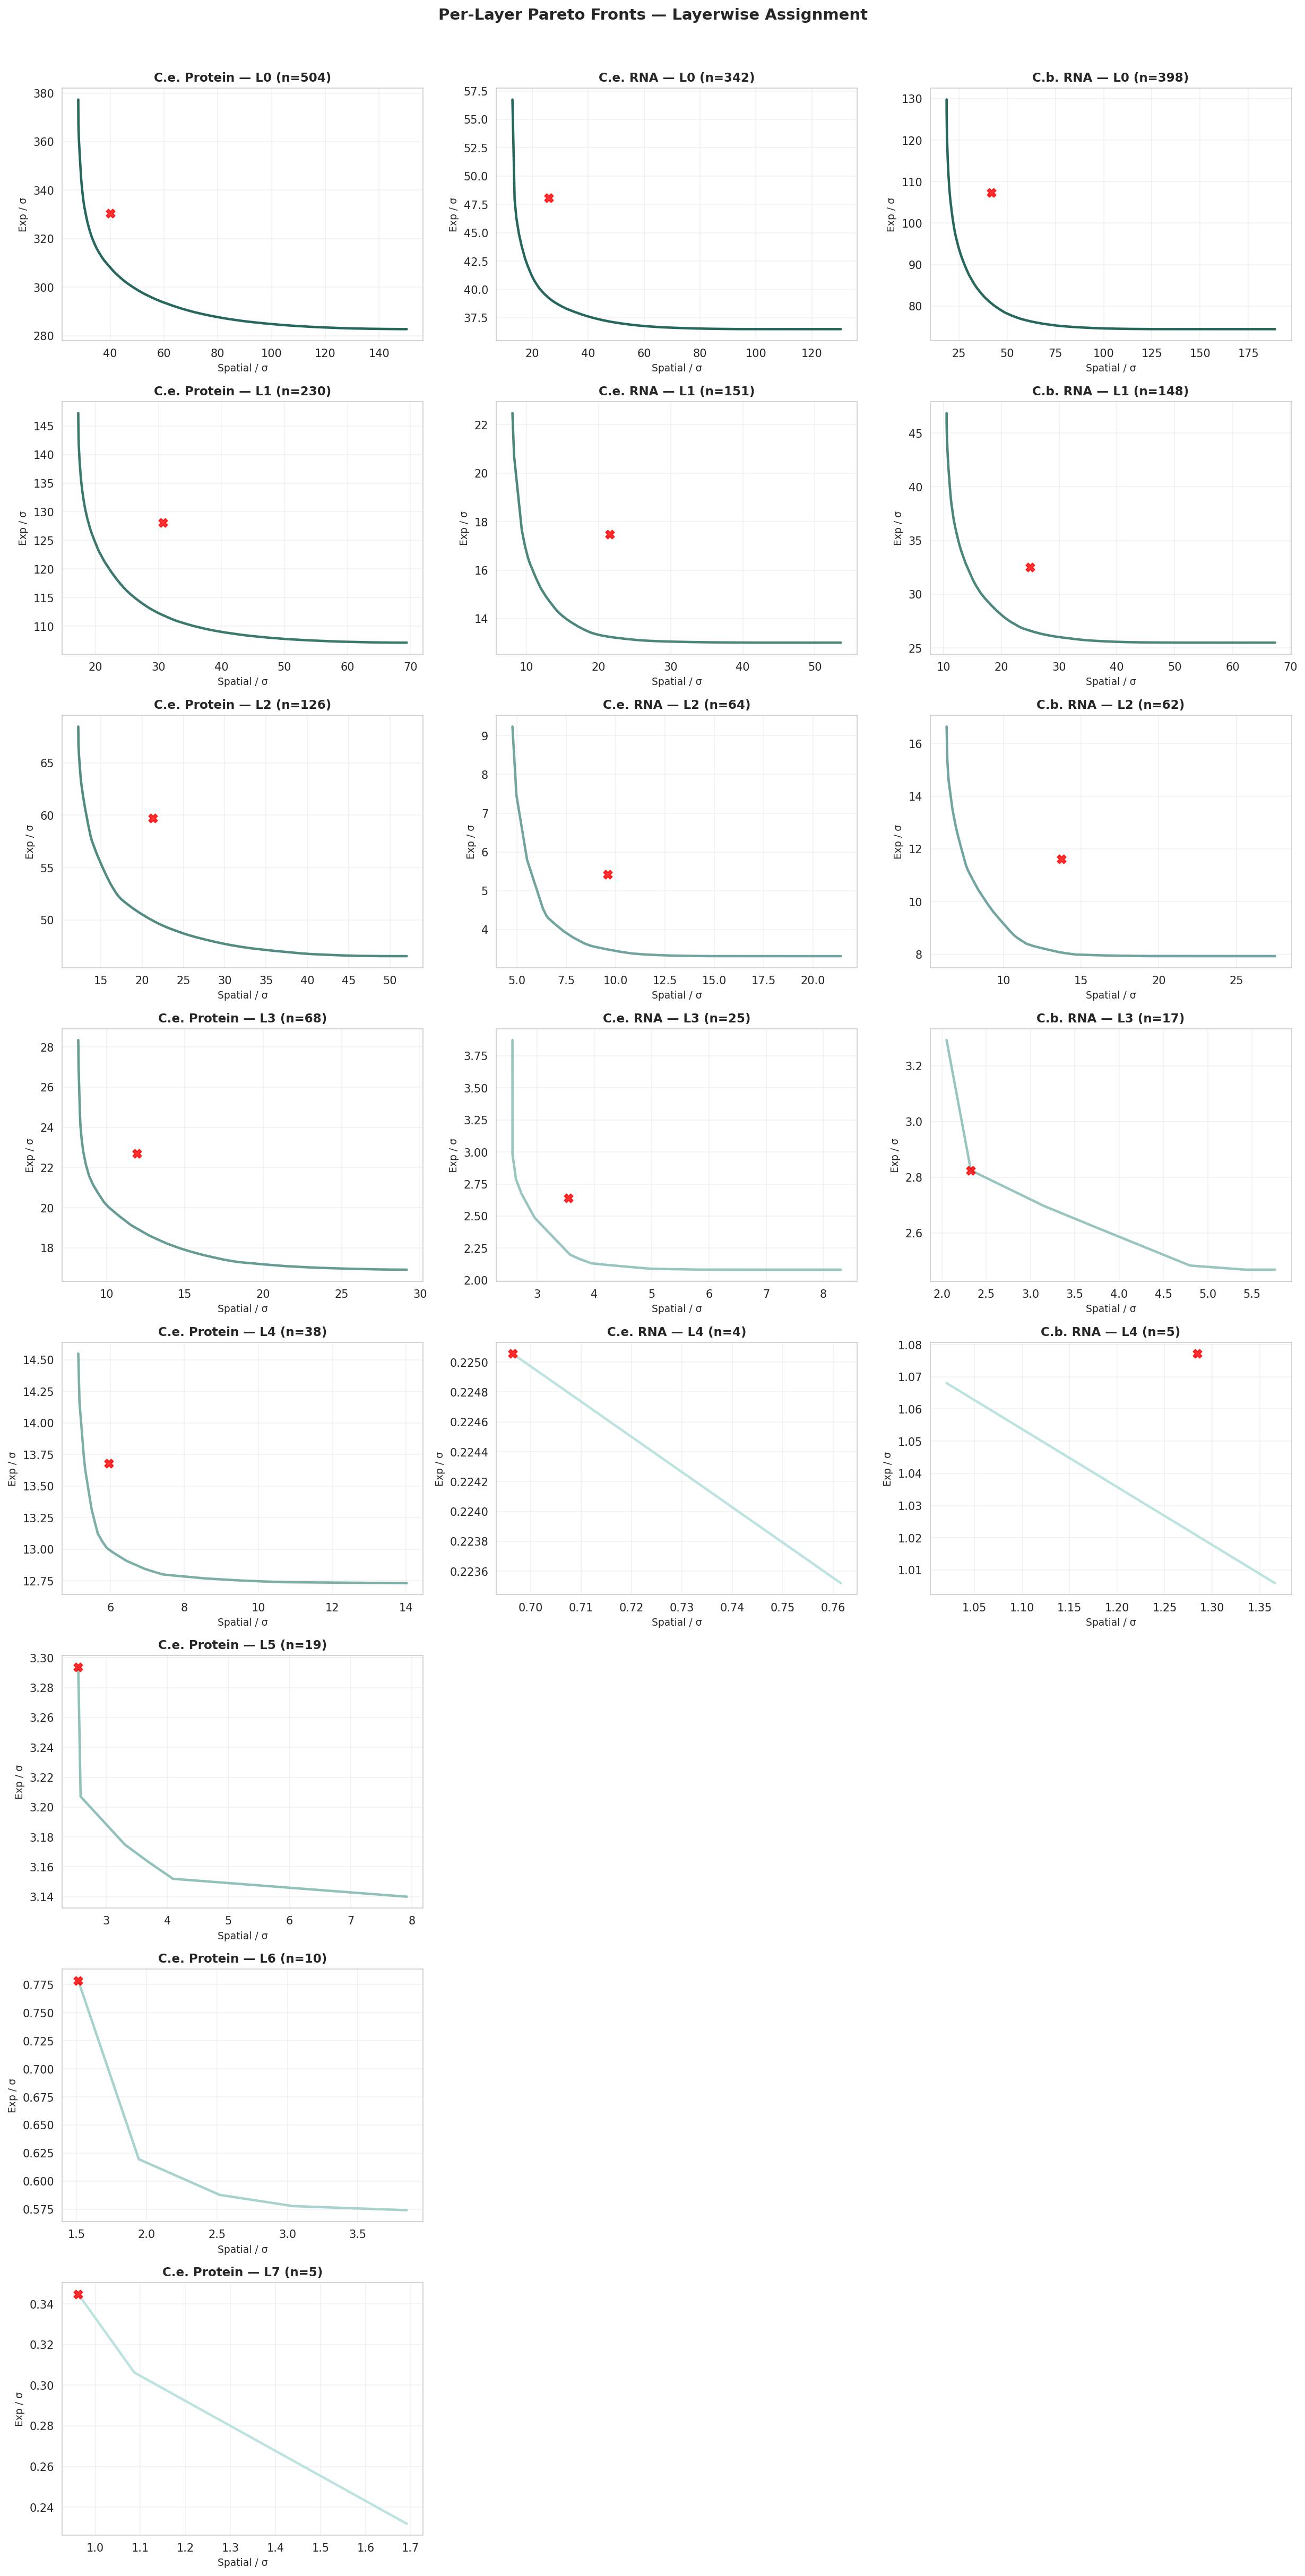

In [22]:
# ── Figure: Per-Layer Pareto Fronts — one subplot per layer per config ──
if LW_DATA:
    n_configs = len(LW_DATA)
    # Determine max layers across configs
    max_layers = max(lw['per_layer_pf'].shape[0] for lw in LW_DATA.values())
    
    fig, axes = plt.subplots(max_layers, n_configs, figsize=(5.5*n_configs, 4*max_layers),
                             squeeze=False)
    
    from matplotlib.colors import LinearSegmentedColormap
    layer_cmap = LinearSegmentedColormap.from_list('layer', ['#004D40', '#B2DFDB'])
    
    for col, (label, lw) in enumerate(LW_DATA.items()):
        per_layer_pf_raw = lw['per_layer_pf']
        per_layer_costs_raw = lw.get('per_layer_costs', None)
        layer_sizes = lw.get('layer_sizes', None)
        n_layers = per_layer_pf_raw.shape[0]
        layer_colors = [layer_cmap(i / max(n_layers - 1, 1)) for i in range(n_layers)]
        
        # Get cousin null for z-scoring
        null_path = os.path.join(CONFIGS[label], 'null', 'random_cousin.npz')
        if os.path.exists(null_path):
            nd = np.load(null_path)
            nz_std = nd['xyz'].std()
            ne_std = nd['exp'].std()
        else:
            nz_std, ne_std = 1, 1
        
        short = label.split('(')[0].strip().replace('C. elegans', 'C.e.').replace('C. briggsae', 'C.b.')
        
        for i in range(n_layers):
            ax = axes[i, col]
            pf_row = per_layer_pf_raw[i]
            pf_x = pf_row[0].astype(float)
            pf_e = pf_row[1].astype(float)
            
            lbl = f'L{i} (n={layer_sizes[i]})' if layer_sizes is not None else f'L{i}'
            ax.plot(pf_x / nz_std, pf_e / ne_std, lw=2.2, alpha=0.85, color=layer_colors[i])
            
            # Diagonal (original lineage) cost marker
            if per_layer_costs_raw is not None and i < per_layer_costs_raw.shape[0]:
                oc_row = per_layer_costs_raw[i]
                ax.scatter(float(oc_row[0]) / nz_std, float(oc_row[1]) / ne_std,
                          color='red', marker='X', s=60, zorder=5, alpha=0.8)
            
            ax.set_title(f'{short} — {lbl}', fontsize=11, fontweight='bold')
            ax.set_xlabel('Spatial / σ', fontsize=9)
            ax.set_ylabel('Exp / σ', fontsize=9)
            ax.grid(True, alpha=0.25)
        
        # Hide unused rows
        for i in range(n_layers, max_layers):
            axes[i, col].set_visible(False)
    
    fig.suptitle('Per-Layer Pareto Fronts — Layerwise Assignment', fontsize=14, fontweight='bold', y=1.01)
    fig.tight_layout()
    plt.show()
else:
    print('No per-layer Pareto data available.')

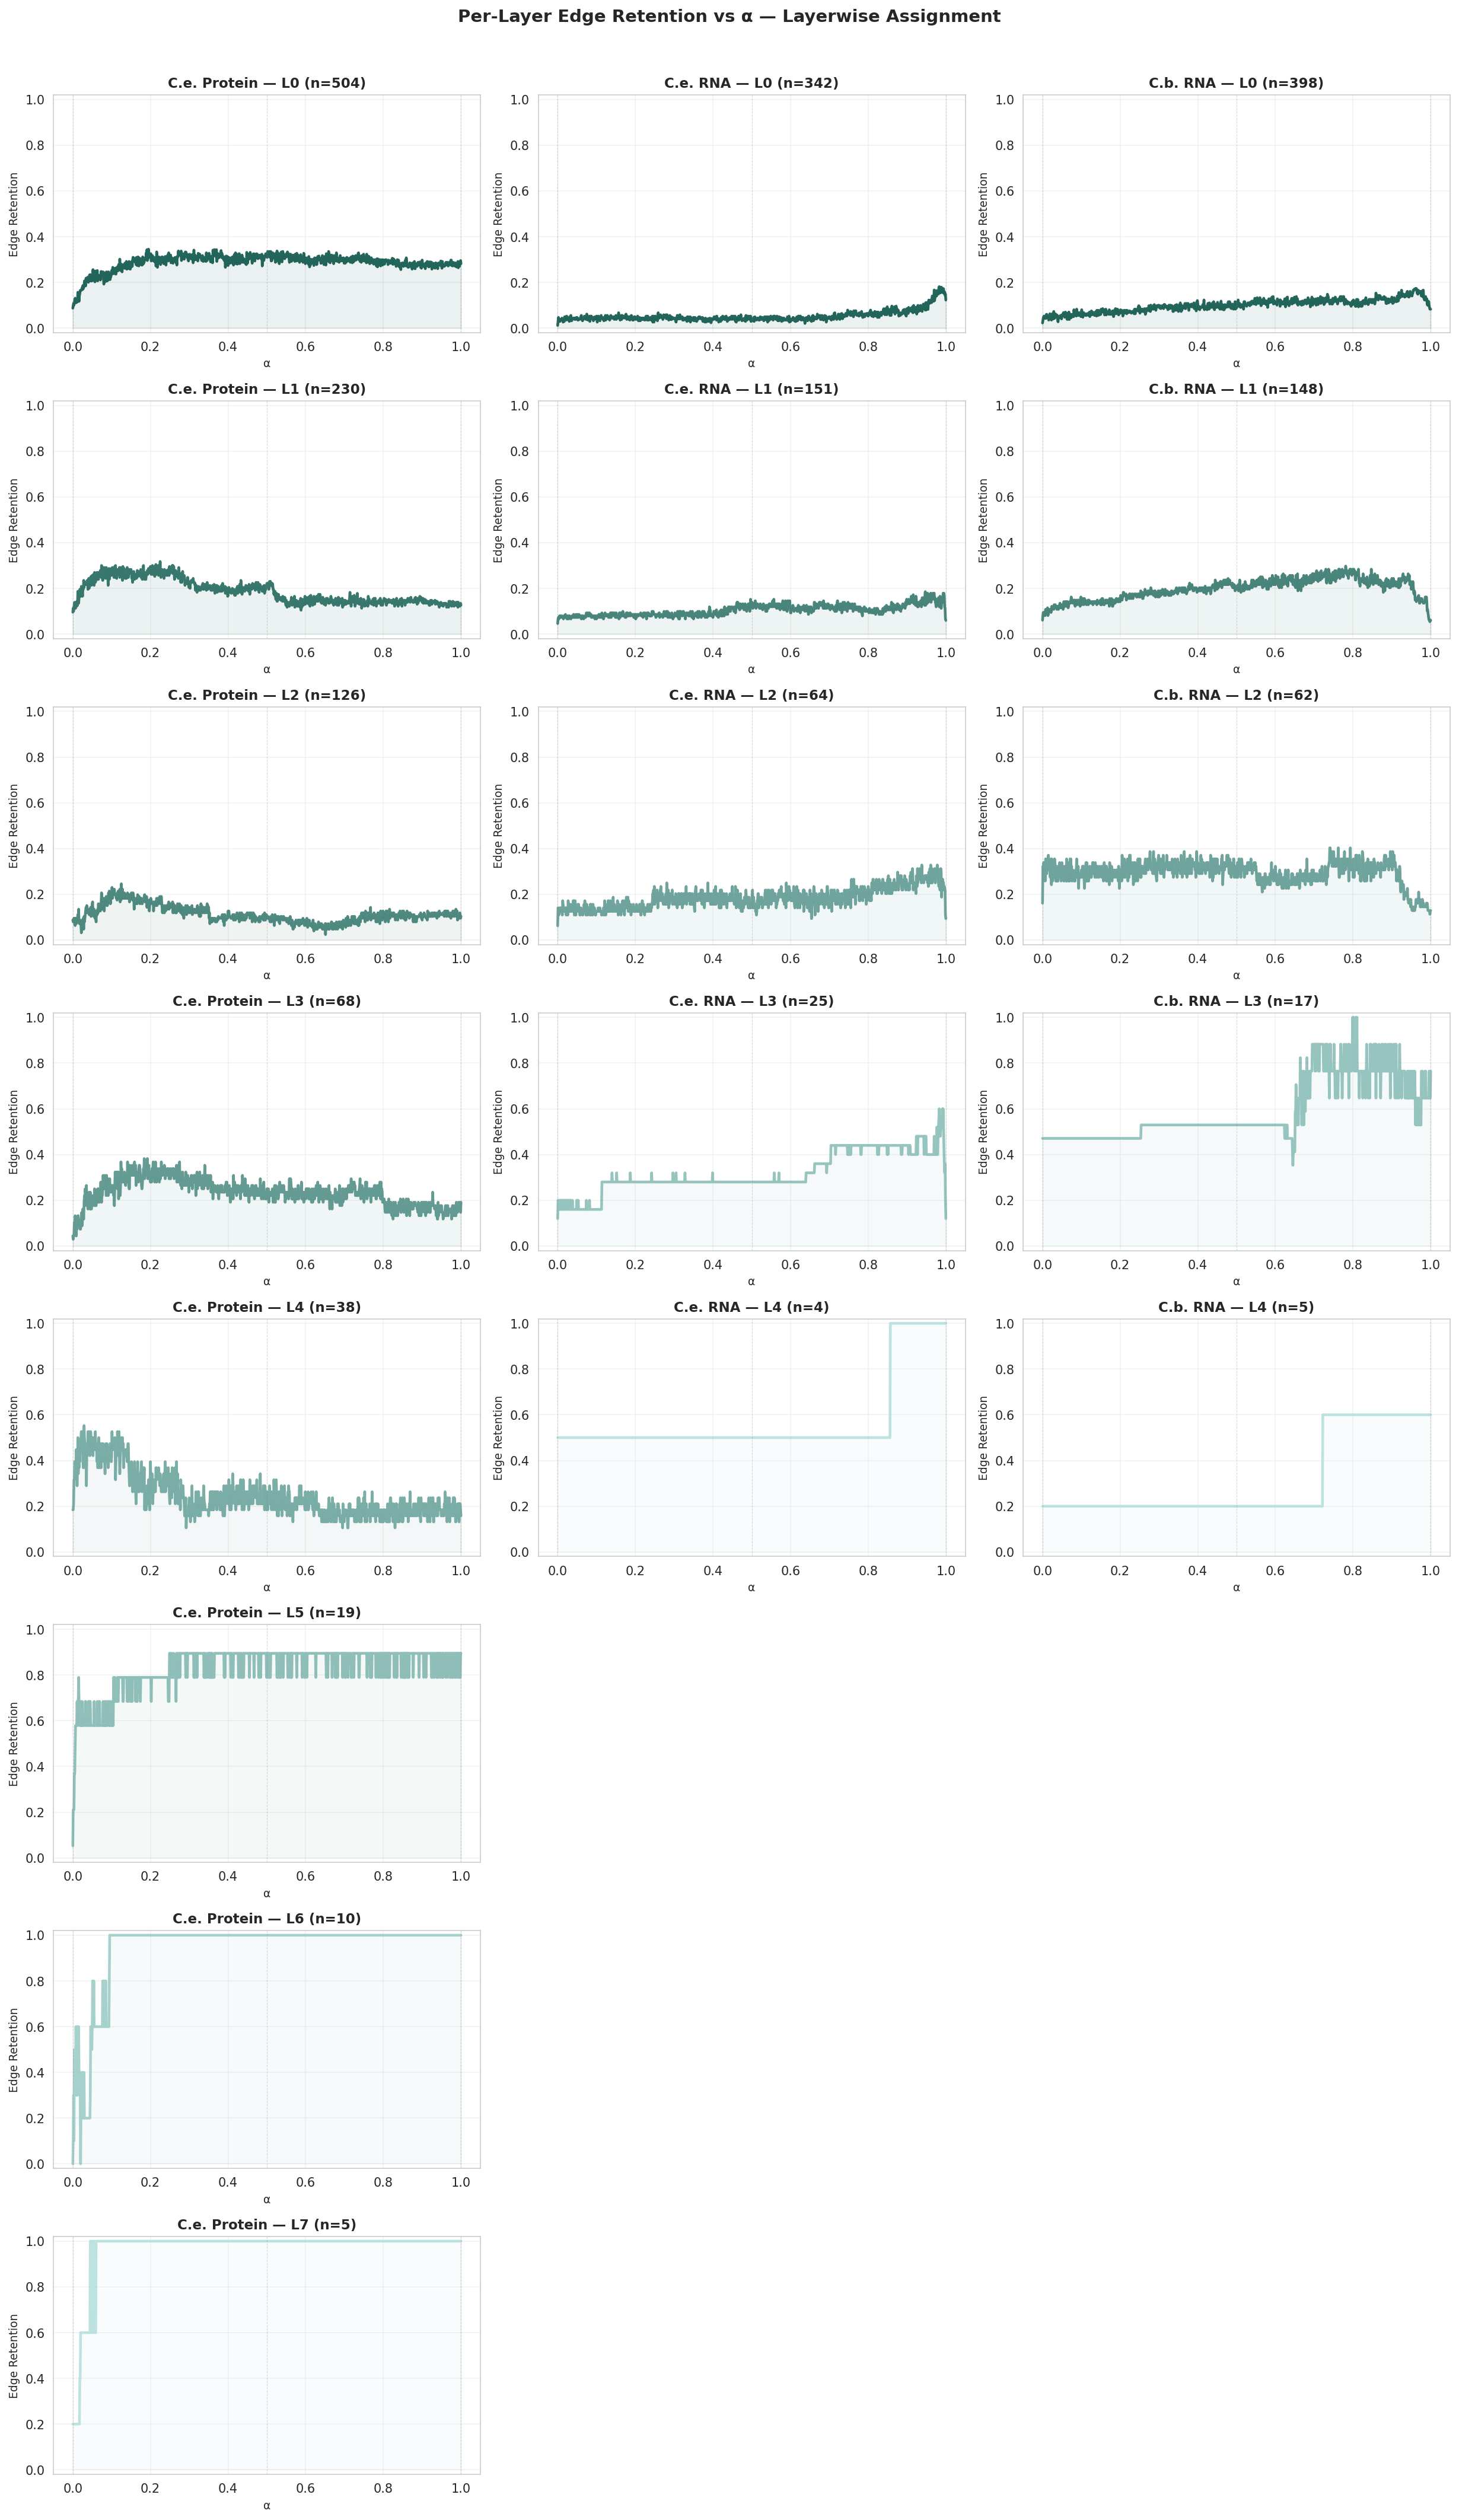

In [23]:
# ── Figure: Per-Layer Edge Retention — one subplot per layer per config ──
if LW_DATA:
    alphas = np.linspace(0, 1, 1001)
    n_configs = len(LW_DATA)
    max_layers = max(lw['per_layer_er'].shape[0] for lw in LW_DATA.values())
    
    fig, axes = plt.subplots(max_layers, n_configs, figsize=(5.5*n_configs, 3.5*max_layers),
                             squeeze=False)
    
    from matplotlib.colors import LinearSegmentedColormap
    layer_cmap = LinearSegmentedColormap.from_list('layer', ['#004D40', '#B2DFDB'])
    
    for col, (label, lw) in enumerate(LW_DATA.items()):
        per_layer_er_raw = lw['per_layer_er']
        layer_sizes = lw.get('layer_sizes', None)
        n_layers = per_layer_er_raw.shape[0]
        layer_colors = [layer_cmap(i / max(n_layers - 1, 1)) for i in range(n_layers)]
        
        short = label.split('(')[0].strip().replace('C. elegans', 'C.e.').replace('C. briggsae', 'C.b.')
        
        for i in range(n_layers):
            ax = axes[i, col]
            er_curve = per_layer_er_raw[i].astype(float)
            
            lbl = f'L{i} (n={layer_sizes[i]})' if layer_sizes is not None else f'L{i}'
            ax.plot(alphas, er_curve, lw=2.2, alpha=0.85, color=layer_colors[i])
            ax.fill_between(alphas, 0, er_curve, alpha=0.08, color=layer_colors[i])
            
            # Annotate ER at key alphas
            for a_idx, a_label in [(0, 'α=0'), (500, 'α=0.5'), (1000, 'α=1')]:
                ax.axvline(x=alphas[a_idx], color='gray', lw=0.5, alpha=0.3, ls='--')
            
            ax.set_title(f'{short} — {lbl}', fontsize=11, fontweight='bold')
            ax.set_xlabel('α', fontsize=9)
            ax.set_ylabel('Edge Retention', fontsize=9)
            ax.set_ylim(-0.02, 1.02)
            ax.grid(True, alpha=0.25)
        
        # Hide unused rows
        for i in range(n_layers, max_layers):
            axes[i, col].set_visible(False)
    
    fig.suptitle('Per-Layer Edge Retention vs α — Layerwise Assignment', fontsize=14, fontweight='bold', y=1.01)
    fig.tight_layout()
    plt.show()
else:
    print('No per-layer ER data available.')

In [24]:
# ── Per-Layer Summary across all configs ──
if LW_DATA:
    for label, lw in LW_DATA.items():
        per_layer_er_raw = lw['per_layer_er']         # (n_layers, 1001) object
        per_layer_pf_raw = lw['per_layer_pf']         # (n_layers, 2, 1001) object
        layer_sizes = lw.get('layer_sizes', None)
        per_layer_costs_raw = lw.get('per_layer_costs', None)
        n_layers = per_layer_er_raw.shape[0]
        
        print(f"\n{'='*80}")
        print(f"  {label}  ({n_layers} layers)")
        print(f"{'='*80}")
        print(f"{'Layer':>6s} {'Size':>5s}  {'ER@α=0':>8s} {'ER@α=0.5':>9s} {'ER@α=1':>8s}  "
              f"{'Best XYZ':>10s} {'Best Exp':>10s}  {'Diag XYZ':>10s} {'Diag Exp':>10s}")
        print('-' * 100)
        
        for i in range(n_layers):
            er = per_layer_er_raw[i].astype(float)    # (1001,) float
            pf_x = per_layer_pf_raw[i][0].astype(float)
            pf_e = per_layer_pf_raw[i][1].astype(float)
            
            n = layer_sizes[i] if layer_sizes is not None else '?'
            oc_x, oc_e = 0, 0
            if per_layer_costs_raw is not None and i < per_layer_costs_raw.shape[0]:
                oc_x = float(per_layer_costs_raw[i][0])
                oc_e = float(per_layer_costs_raw[i][1])
            
            print(f'  L{i:>3d}  {str(n):>5s}  {er[0]:>7.3f}  {er[500]:>8.3f}  {er[-1]:>7.3f}  '
                  f'{pf_x.min():>9.0f}  {pf_e.min():>9.0f}  {oc_x:>9.0f}  {oc_e:>9.0f}')
        
        # Overall stats
        er_all = np.array([per_layer_er_raw[i].astype(float) for i in range(n_layers)])
        print(f'\n  Mean ER across layers: α=0: {er_all[:,0].mean():.3f}, '
              f'α=0.5: {er_all[:,500].mean():.3f}, α=1: {er_all[:,-1].mean():.3f}')
        best_layer = np.argmax(er_all.mean(axis=1))
        print(f'  Layer {best_layer} (size={layer_sizes[best_layer]}) has highest mean ER: {er_all[best_layer].mean():.3f}')
else:
    print('No per-layer data available.')


  C. elegans Protein (3D, T≤255)  (8 layers)
 Layer  Size    ER@α=0  ER@α=0.5   ER@α=1    Best XYZ   Best Exp    Diag XYZ   Diag Exp
----------------------------------------------------------------------------------------------------
  L  0    504    0.087     0.315    0.282       1092       1569       1558       1834
  L  1    230    0.096     0.222    0.126        670        595       1192        711
  L  2    126    0.087     0.103    0.103        476        258        826        331
  L  3     68    0.044     0.250    0.191        318         94        464        126
  L  4     38    0.184     0.263    0.158        199         71        231         76
  L  5     19    0.053     0.895    0.895         99         17         99         18
  L  6     10    0.000     1.000    1.000         59          3         59          4
  L  7      5    0.200     1.000    1.000         37          1         37          2

  Mean ER across layers: α=0: 0.094, α=0.5: 0.506, α=1: 0.469
  Layer 7 (siz

---
## Part 3: Cross-Config Comparison Plots

Comparing full-tree Pareto results across 3 data configurations:
- **C. elegans Protein** (top20 z-scored, embryo1 T≤255, 3D)
- **C. elegans RNA** (top20 TFs, embryo1 T≤230, 2D xy-only)
- **C. briggsae RNA** (top20 TFs, new tracking T≤148, 2D xy-only)

2D xy-only used for RNA comparison due to lower z-axis accuracy in briggsae tracking.
All results pre-computed and cached. Uses cousin-randomized null for std scaling.

In [25]:
# ── Load results from all 3 configs (CONFIGS & LINEAGE_COSTS defined in setup) ──
all_null = {}
all_heur = {}

for label, out_dir in CONFIGS.items():
    null_dir = os.path.join(out_dir, 'null')
    heur_dir = os.path.join(out_dir, 'heuristics')
    
    # Load null data
    null_data = {}
    for fname in ['random_full', 'random_by_layer', 'random_cousin', 'random_rebuild']:
        p = os.path.join(null_dir, f'{fname}.npz')
        if os.path.exists(p):
            d = np.load(p)
            null_data[fname.replace('random_', 'Random ').replace('_', ' ')] = (d['xyz'], d['exp'])
    all_null[label] = null_data
    
    # Load heuristic data
    heur_data = {}
    heur_names = [('Bottom-up by layer', 'bottom_up_by_layer'),
                  ('Layerwise Pareto assign.', 'layerwise_pareto_assignment'),
                  ('Paired bottom-up', 'paired_bottom_up'),
                  ('MST rebuild', 'mst_rebuild'),
                  ('Top-down rebuild', 'top_down_rebuild'),
                  ('Terminal-only (no repl.)', 'terminal_only_no_replacement')]
    for hname, fname in heur_names:
        p = os.path.join(heur_dir, f'{fname}.npz')
        if os.path.exists(p):
            d = dict(np.load(p, allow_pickle=True))
            heur_data[hname] = (d['xyz'], d['exp'])
    all_heur[label] = heur_data
    
    print(f'{label}: {len(null_data)} null, {len(heur_data)} heuristics')

C. elegans Protein (3D, T≤255): 4 null, 6 heuristics
C. elegans RNA (2D, T≤230): 4 null, 6 heuristics
C. briggsae RNA (2D, T≤148): 4 null, 6 heuristics


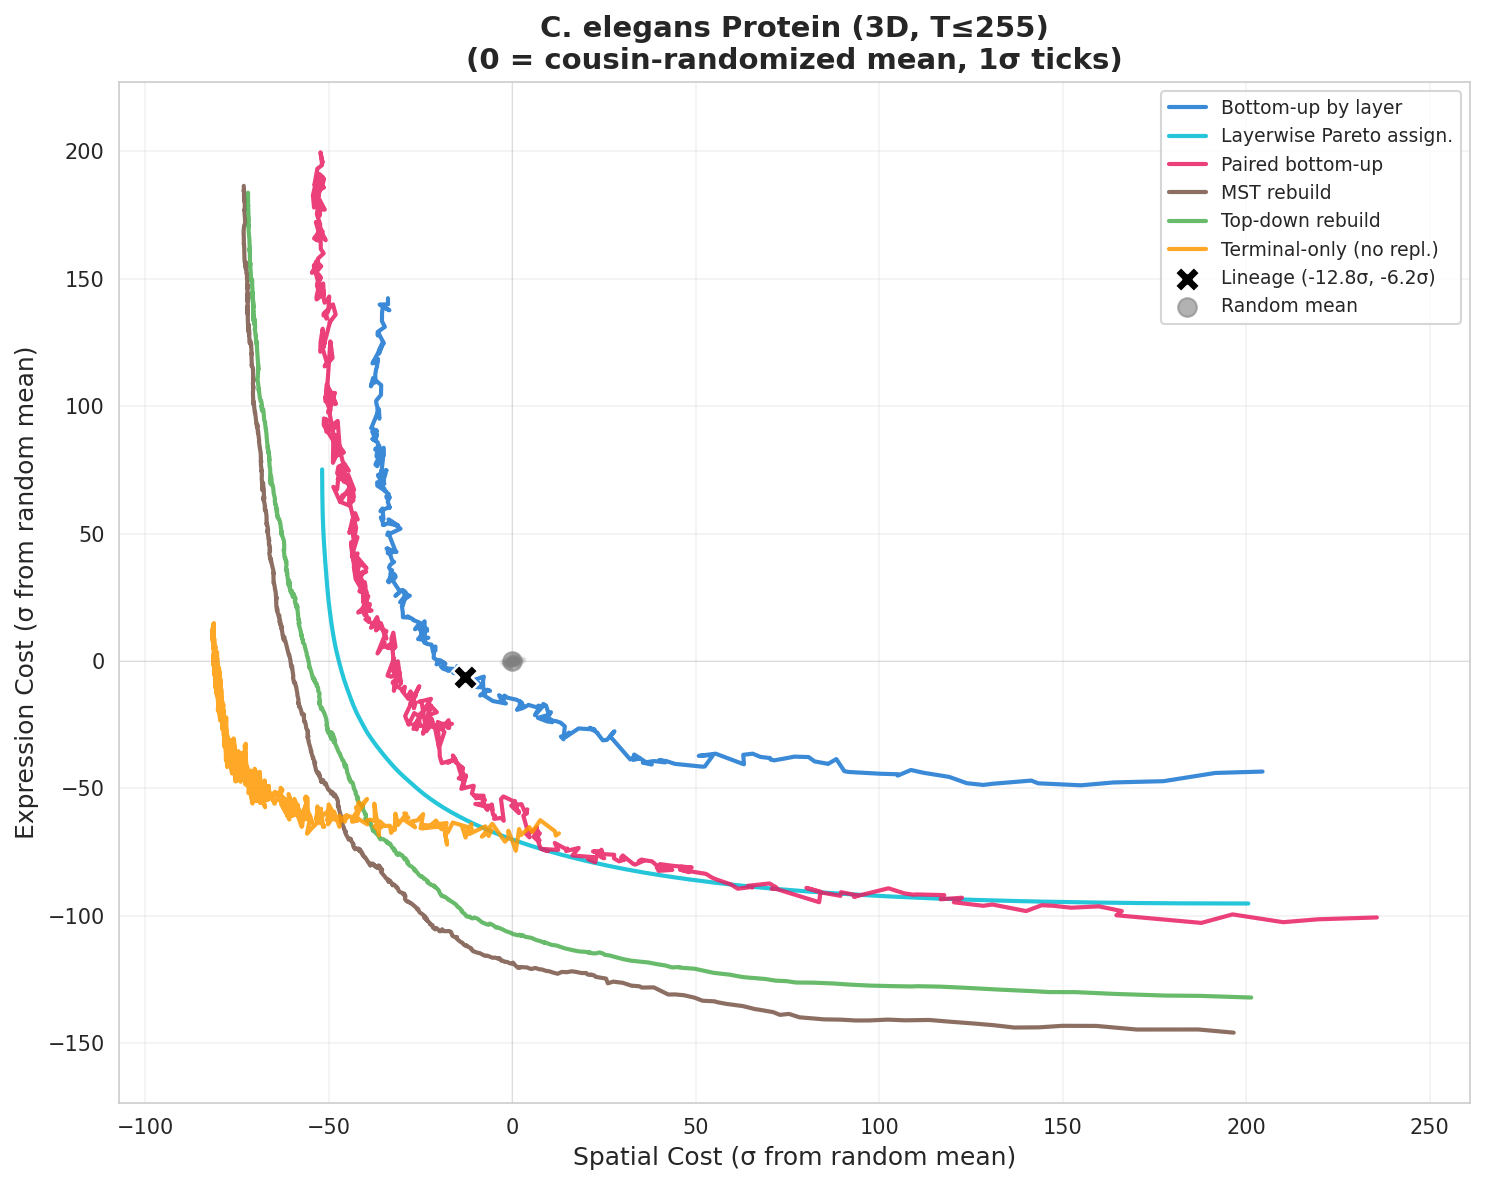

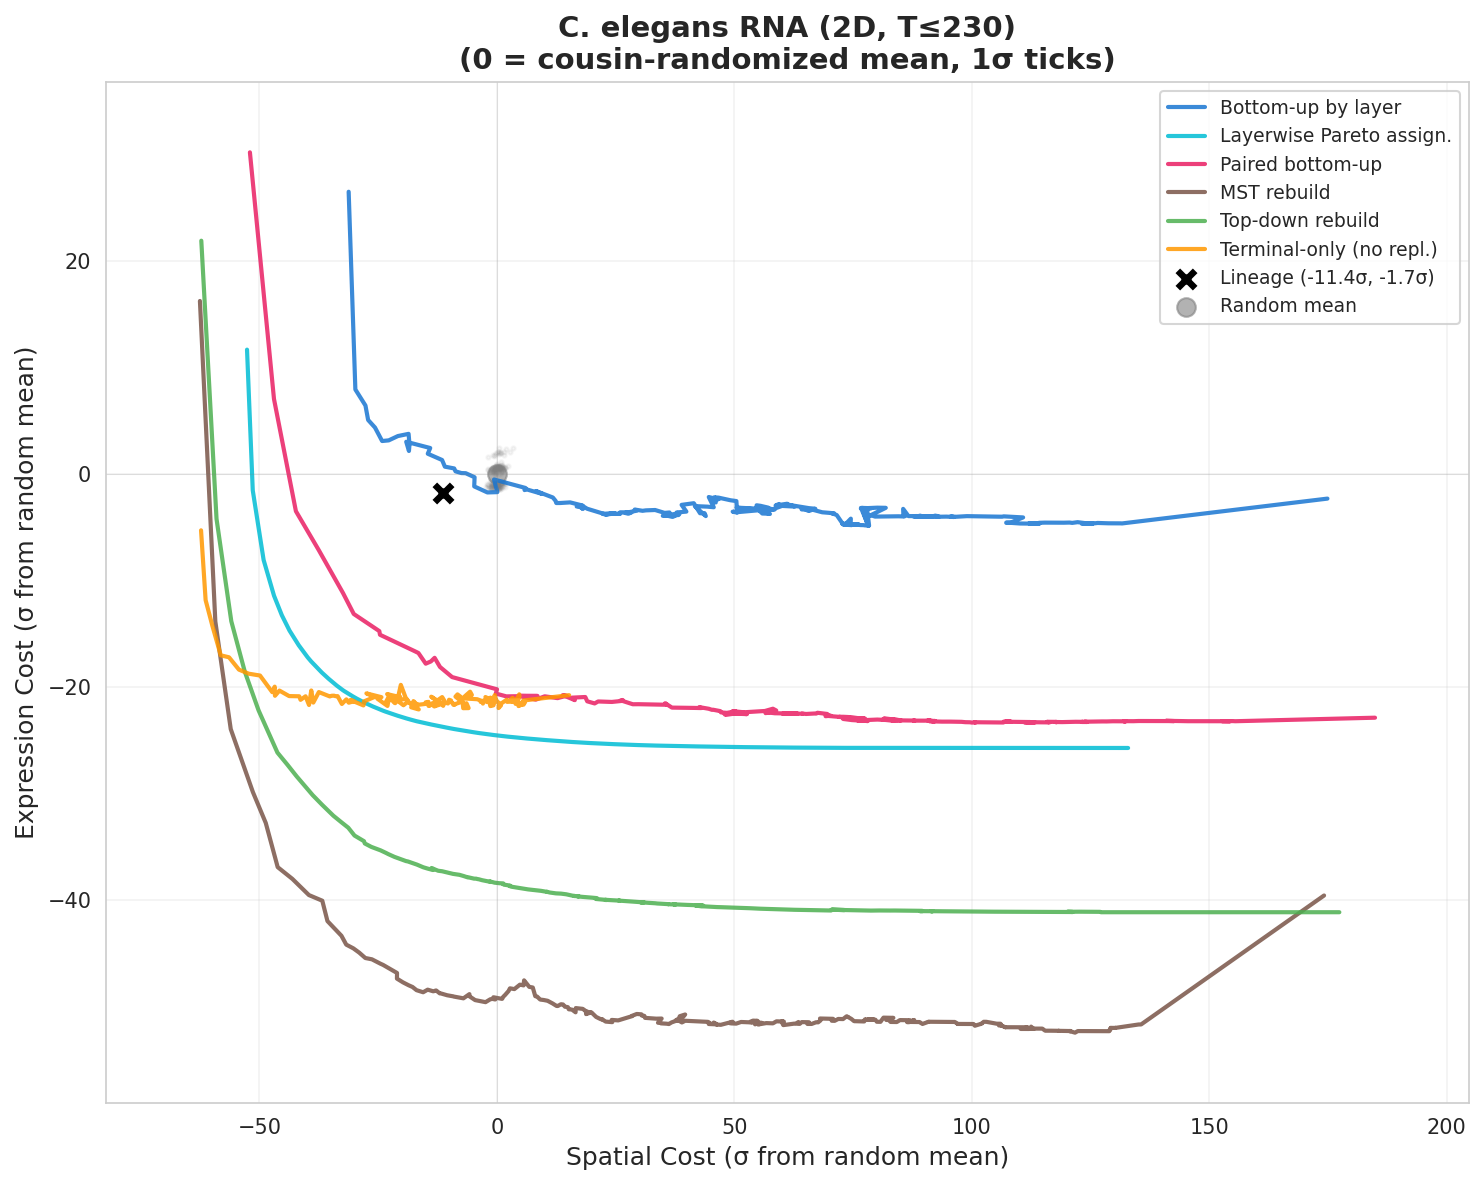

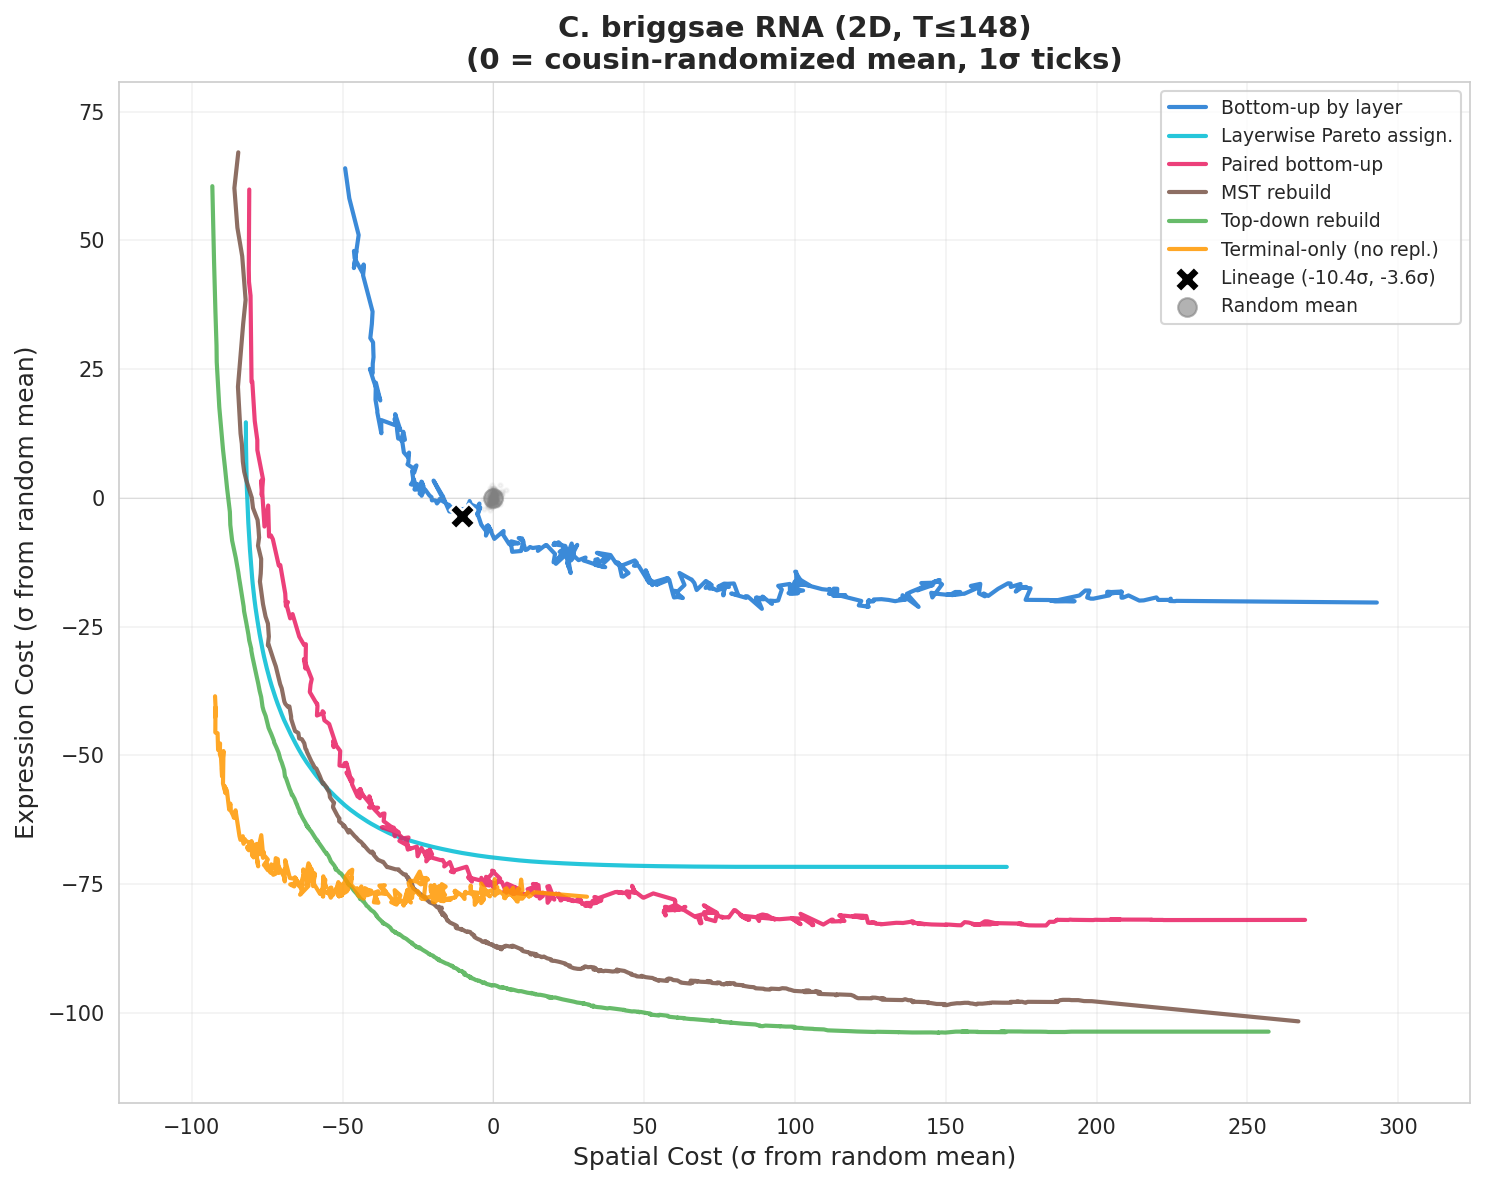

In [26]:
# ── Figure 1: Individual Pareto Fronts (one per config, for slide embedding) ──
# Each dataset scaled by its own cousin-randomized std, centered at random cousin mean
heuristic_colors = {
    'Bottom-up by layer':         '#1976D2',
    'Layerwise Pareto assign.':   '#00BCD4',
    'Paired bottom-up':           '#E91E63', 
    'MST rebuild':                '#795548',
    'Top-down rebuild':           '#4CAF50',
    'Terminal-only (no repl.)':   '#FF9800',
}

for label, lcost in LINEAGE_COSTS.items():
    null_data = all_null[label]
    heur_data = all_heur[label]
    lx_raw, le_raw = lcost
    
    # Zero-center using cousin-randomized mean & std
    if 'Random cousin' in null_data:
        nz, ne = null_data['Random cousin']
        xs, es = nz.std(), ne.std()
        xm, em = nz.mean(), ne.mean()
    else:
        xs, es = 1, 1
        xm, em = 0, 0
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot each heuristic Pareto front
    for name, (xz, ex) in heur_data.items():
        xz, ex = np.array(xz), np.array(ex)
        c = heuristic_colors.get(name, 'gray')
        ax.plot((xz - xm)/xs, (ex - em)/es, lw=2, alpha=0.85, label=name, color=c)
    
    # Lineage position (zero-centered)
    lx = (lx_raw - xm) / xs
    le = (le_raw - em) / es
    ax.scatter(lx, le, color='black', marker='X', s=150, zorder=10,
              edgecolors='white', lw=1.2, label=f'Lineage ({lx:.1f}σ, {le:.1f}σ)')
    
    # Random cousin scatter (sparse sample)
    if 'Random cousin' in null_data:
        ax.scatter((nz[::500] - xm)/xs, (ne[::500] - em)/es, color='gray', alpha=0.08, s=4)
    
    # Origin = random cousin mean
    ax.scatter(0, 0, color='gray', marker='o', s=80, alpha=0.6, label='Random mean')
    ax.axhline(y=0, color='gray', lw=0.5, alpha=0.2)
    ax.axvline(x=0, color='gray', lw=0.5, alpha=0.2)
    
    # Zoom to Pareto front region
    all_x = np.concatenate([np.array(xz) for xz, _ in heur_data.values()])
    all_e = np.concatenate([np.array(ex) for _, ex in heur_data.values()])
    x_pad = (all_x.max() - all_x.min()) * 0.08
    e_pad = (all_e.max() - all_e.min()) * 0.08
    ax.set_xlim((all_x.min() - xm - x_pad)/xs, (all_x.max() - xm + x_pad)/xs)
    ax.set_ylim((all_e.min() - em - e_pad)/es, (all_e.max() - em + e_pad)/es)
    
    ax.set_xlabel('Spatial Cost (σ from random mean)', fontsize=12)
    ax.set_ylabel('Expression Cost (σ from random mean)', fontsize=12)
    ax.set_title(f'{label}\n(0 = cousin-randomized mean, 1σ ticks)', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.25)
    
    fig.tight_layout()
    plt.show()

In [27]:
# ── Summary Table: Best Costs Across Configs ──
rows = []
for label in CONFIGS:
    lx, le = LINEAGE_COSTS[label]
    heur_data = all_heur[label]
    for hname, (xz, ex) in heur_data.items():
        xz, ex = np.array(xz), np.array(ex)
        rows.append({
            'Dataset': label,
            'Heuristic': hname,
            'Best XYZ': f'{xz.min():.0f}',
            'Δ XYZ': f'{(xz.min()-lx)/lx*100:+.1f}%',
            'Best Exp': f'{ex.min():.0f}',
            'Δ Exp': f'{(ex.min()-le)/le*100:+.1f}%',
        })

summary_df = pd.DataFrame(rows)
display(summary_df.set_index(['Dataset', 'Heuristic']))
summary_df

Best XYZ   Δ XYZ  \
Dataset                        Heuristic                                   
C. elegans Protein (3D, T≤255) Bottom-up by layer           3467  -22.4%   
                               Layerwise Pareto assign.     2951  -33.9%   
                               Paired bottom-up             2843  -36.3%   
                               MST rebuild                  2120  -52.5%   
                               Top-down rebuild             2166  -51.5%   
                               Terminal-only (no repl.)     1788  -59.9%   
C. elegans RNA (2D, T≤230)     Bottom-up by layer           1833  -28.2%   
                               Layerwise Pareto assign.     1054  -58.7%   
                               Paired bottom-up             1076  -57.8%   
                               MST rebuild                   693  -72.8%   
                               Top-down rebuild              704  -72.4%   
                               Terminal-only (no repl.)      702  -72.5%   
C. briggsae RNA (2D, T≤148)    Bottom-up by layer          26688  -35.2%   
                               Layerwise Pareto assign.    14394  -65.0%   
                               Paired bottom-up            14755  -64.2%   
                               MST rebuild                 12970  -68.5%   
                               Top-down rebuild            10240  -75.1%   
                               Terminal-only (no repl.)    10577  -74.3%   

                                                        Best Exp   Δ Exp  
Dataset                        Heuristic                                  
C. elegans Protein (3D, T≤255) Bottom-up by layer           2866   -7.6%  
                               Layerwise Pareto assign.     2609  -15.9%  
                               Paired bottom-up             2566  -17.3%  
                               MST rebuild                  2327  -25.0%  
                               Top-down rebuild             2404  -22.5%  
                               Terminal-only (no repl.)     2723  -12.2%  
C. elegans RNA (2D, T≤230)     Bottom-up by layer         700200   -4.0%  
                               Layerwise Pareto assign.   507935  -30.3%  
                               Paired bottom-up           529913  -27.3%  
                               MST rebuild                261460  -64.1%  
                               Top-down rebuild           365702  -49.8%  
                               Terminal-only (no repl.)   541293  -25.7%  
C. briggsae RNA (2D, T≤148)    Bottom-up by layer         867126  -10.0%  
                               Layerwise Pareto assign.   597870  -38.0%  
                               Paired bottom-up           536730  -44.3%  
                               MST rebuild                436718  -54.7%  
                               Top-down rebuild           424929  -55.9%  
                               Terminal-only (no repl.)   557542  -42.1%

,Dataset,Heuristic,Best XYZ,Δ XYZ,Best Exp,Δ Exp
0,"C. elegans Protein (3D, T≤255)",Bottom-up by layer,3467,-22.4%,2866,-7.6%
1,"C. elegans Protein (3D, T≤255)",Layerwise Pareto assign.,2951,-33.9%,2609,-15.9%
2,"C. elegans Protein (3D, T≤255)",Paired bottom-up,2843,-36.3%,2566,-17.3%
3,"C. elegans Protein (3D, T≤255)",MST rebuild,2120,-52.5%,2327,-25.0%
4,"C. elegans Protein (3D, T≤255)",Top-down rebuild,2166,-51.5%,2404,-22.5%
5,"C. elegans Protein (3D, T≤255)",Terminal-only (no repl.),1788,-59.9%,2723,-12.2%
6,"C. elegans RNA (2D, T≤230)",Bottom-up by layer,1833,-28.2%,700200,-4.0%
7,"C. elegans RNA (2D, T≤230)",Layerwise Pareto assign.,1054,-58.7%,507935,-30.3%
8,"C. elegans RNA (2D, T≤230)",Paired bottom-up,1076,-57.8%,529913,-27.3%
9,"C. elegans RNA (2D, T≤230)",MST rebuild,693,-72.8%,261460,-64.1%


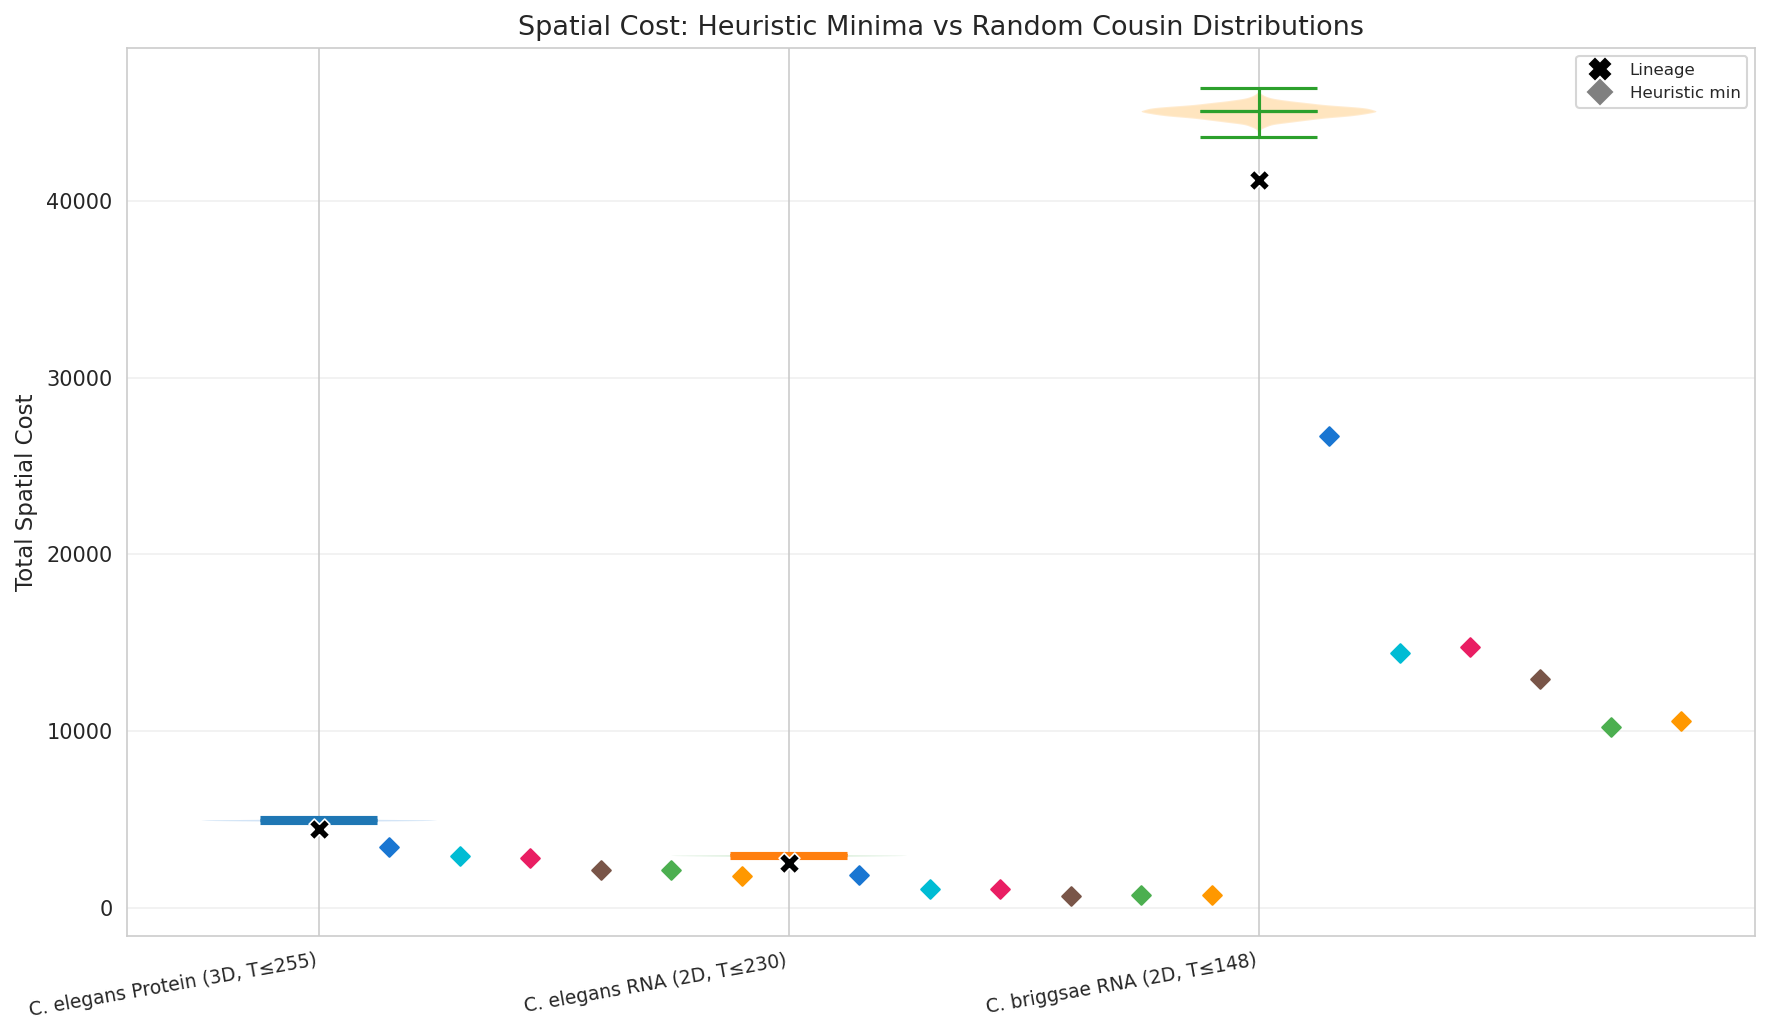

In [28]:
# ── Figure 2: Lineage z-scores vs Random Cousin (all configs) ──
fig, ax = plt.subplots(figsize=(12, 7))

config_colors = ['#1976D2', '#4CAF50', '#FF9800']
x_pos = 0
all_labels = []
all_x_ticks = []

for (label, lcost), c_color in zip(LINEAGE_COSTS.items(), config_colors):
    null_data = all_null[label]
    lx_raw, le_raw = lcost
    
    if 'Random cousin' not in null_data:
        continue
    
    nz, ne = null_data['Random cousin']
    xs, es = nz.std(), ne.std()
    
    # Violin of random cousin xyz
    sample = np.random.choice(nz, min(5000, len(nz)), replace=False)
    parts = ax.violinplot(sample, positions=[x_pos], showmeans=True, showmedians=True)
    for pc in parts['bodies']:
        pc.set_facecolor(c_color)
        pc.set_alpha(0.25)
    
    # Lineage marker
    ax.scatter(x_pos, lx_raw, color='black', marker='X', s=100, zorder=10,
              edgecolors='white', lw=0.8)
    
    # Heuristic minima
    heur_data = all_heur[label]
    for j, (hname, (xz, _)) in enumerate(heur_data.items()):
        ax.scatter(x_pos + 0.15*(j+1), np.array(xz).min(),
                  color=heuristic_colors.get(hname, 'gray'), marker='D', s=40, zorder=8)
    
    all_labels.append(label)
    all_x_ticks.append(x_pos)
    x_pos += 1

ax.set_xticks(all_x_ticks)
ax.set_xticklabels(all_labels, rotation=10, ha='right', fontsize=9)
ax.set_ylabel('Total Spatial Cost', fontsize=11)
ax.set_title('Spatial Cost: Heuristic Minima vs Random Cousin Distributions', fontsize=13)
ax.legend(handles=[Line2D([0], [0], color='black', marker='X', ls='', markersize=10, label='Lineage'),
                    Line2D([0], [0], marker='D', color='gray', ls='', markersize=8, label='Heuristic min')],
          fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
fig.tight_layout()
plt.show()

In [29]:
# ── Final Summary ──
print('=' * 65)
print('FULL-TREE PARETO — CROSS-CONFIG COMPARISON')
print('=' * 65)
for label in CONFIGS:
    lx, le = LINEAGE_COSTS[label]
    n_null = len(all_null[label])
    n_heur = len(all_heur[label])
    heur_data = all_heur[label]
    best_xyz = min(np.array(xz).min() for xz, _ in heur_data.values())
    best_exp = min(np.array(ex).min() for _, ex in heur_data.values())
    print(f'\n{label}:')
    print(f'  Lineage: xyz={lx:.1f}, exp={le:.1f}')
    print(f'  {n_heur} heuristics, best xyz={best_xyz:.0f} ({(best_xyz-lx)/lx*100:+.1f}%), best exp={best_exp:.0f} ({(best_exp-le)/le*100:+.1f}%)')
    if 'Random cousin' in all_null[label]:
        nz, ne = all_null[label]['Random cousin']
        print(f'  Cousin null z-score: xyz={(lx-nz.mean())/nz.std():+.1f}σ, exp={(le-ne.mean())/ne.std():+.1f}σ')
print('\nDone!')

FULL-TREE PARETO — CROSS-CONFIG COMPARISON

C. elegans Protein (3D, T≤255):
  Lineage: xyz=4465.5, exp=3102.4
  6 heuristics, best xyz=1788 (-59.9%), best exp=2327 (-25.0%)
  Cousin null z-score: xyz=-12.8σ, exp=-6.2σ

C. elegans RNA (2D, T≤230):
  Lineage: xyz=2553.6, exp=729014.5
  6 heuristics, best xyz=693 (-72.8%), best exp=261460 (-64.1%)
  Cousin null z-score: xyz=-11.4σ, exp=-1.7σ

C. briggsae RNA (2D, T≤148):
  Lineage: xyz=41159.5, exp=963757.9
  6 heuristics, best xyz=10240 (-75.1%), best exp=424929 (-55.9%)
  Cousin null z-score: xyz=-10.4σ, exp=-3.6σ

Done!
